**Program**: 3a_PISA_QQ Plots<br>
**Group**: Spring 2025, Data Mining, Final Project, Group 11<br>
**Group Members**: Sean Fitzgerald, Nick Mobus, Vanessa Thorsten<br>
**Description**: This program reads in the analysis dataset dfCOG.csv, which includes country level data from the PISA student testing, SES, student questionnaire, as well as GDP and percent GDP spent on education by country. Continuous variables are normalized and QQ plots are assessed.<br>
**Output**: An output dataset including the normalized variables is created.<br>
**Program History/Modifications**:<br>
03/17/2025 Initial Version

In [1]:
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import numpy as np

In [2]:
dfPISA = pd.read_csv("dfCOG.csv", usecols= ["math_all_mean","read_all_mean","scie_all_mean","ses_all_mean","country_gdp", "ed_percent_gdp"])
dfPISA.head()


,math_all_mean,read_all_mean,scie_all_mean,ses_all_mean,country_gdp,ed_percent_gdp
0,417,404,421,-0.27,29536.6780,4.730330
1,336,329,347,-2.01,6225.5327,2.951152
2,497,507,515,0.38,55781.7000,4.139572
3,412,448,444,-0.51,29105.1020,4.999240
4,547,515,537,-0.19,NaN,4.615470


In [3]:
country_codes = pd.read_csv("dfCOG.csv", usecols= ["CNTRYID"])
country_codes.head()

,CNTRYID
0,100
1,116
2,124
3,152
4,158


In [4]:
mean_PISA = dfPISA.mean()
sd_PISA = dfPISA.std()

In [5]:
dfPISA[["Normalized_Math", "Normalized_Read","Normalized_Scie","Normalized_SES", "Normalized_GDP", "Normalized_Ed_Percent_GDP"]] = (dfPISA - mean_PISA)/sd_PISA

In [6]:
dfPISA.head()

,math_all_mean,read_all_mean,scie_all_mean,ses_all_mean,country_gdp,ed_percent_gdp,Normalized_Math,Normalized_Read,Normalized_Scie,Normalized_SES,Normalized_GDP,Normalized_Ed_Percent_GDP
0,417,404,421,-0.27,29536.6780,4.730330,-0.354941,-0.552826,-0.464034,0.150197,-0.415320,0.190766
1,336,329,347,-2.01,6225.5327,2.951152,-1.746911,-1.889244,-1.791681,-2.832321,-1.292559,-1.350023
2,497,507,515,0.38,55781.7000,4.139572,1.019845,1.282521,1.222436,1.264356,0.572325,-0.320838
3,412,448,444,-0.51,29105.1020,4.999240,-0.440865,0.231206,-0.051387,-0.261185,-0.431561,0.423646
4,547,515,537,-0.19,NaN,4.615470,1.879086,1.425072,1.617142,0.287325,NaN,0.091296


In [7]:
dfPISA = pd.concat([country_codes, dfPISA], axis=1)
dfPISA.head()

,CNTRYID,math_all_mean,read_all_mean,scie_all_mean,ses_all_mean,country_gdp,ed_percent_gdp,Normalized_Math,Normalized_Read,Normalized_Scie,Normalized_SES,Normalized_GDP,Normalized_Ed_Percent_GDP
0,100,417,404,421,-0.27,29536.6780,4.730330,-0.354941,-0.552826,-0.464034,0.150197,-0.415320,0.190766
1,116,336,329,347,-2.01,6225.5327,2.951152,-1.746911,-1.889244,-1.791681,-2.832321,-1.292559,-1.350023
2,124,497,507,515,0.38,55781.7000,4.139572,1.019845,1.282521,1.222436,1.264356,0.572325,-0.320838
3,152,412,448,444,-0.51,29105.1020,4.999240,-0.440865,0.231206,-0.051387,-0.261185,-0.431561,0.423646
4,158,547,515,537,-0.19,NaN,4.615470,1.879086,1.425072,1.617142,0.287325,NaN,0.091296


In [8]:
dfPISA.to_csv("PISA_Normalized_Data.csv")

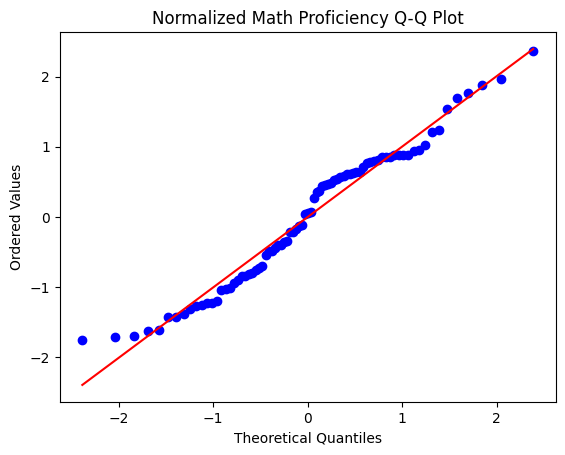

In [9]:
stats.probplot(dfPISA["Normalized_Math"], dist="norm", plot=plt)
plt.title('Normalized Math Proficiency Q-Q Plot')
plt.xlabel('Theoretical Quantiles')
plt.ylabel('Ordered Values')
plt.show()

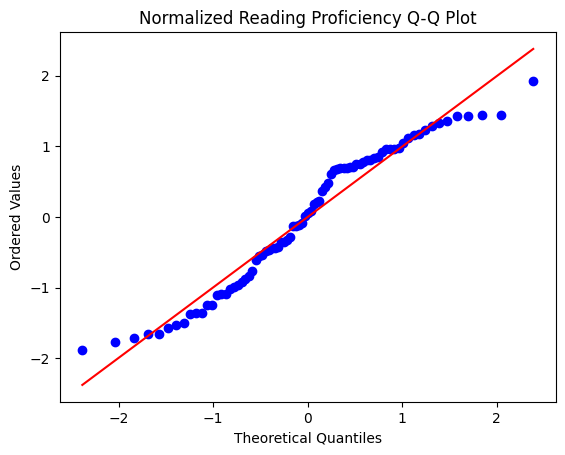

In [10]:
stats.probplot(dfPISA["Normalized_Read"], dist="norm", plot=plt)
plt.title('Normalized Reading Proficiency Q-Q Plot')
plt.xlabel('Theoretical Quantiles')
plt.ylabel('Ordered Values')
plt.show()

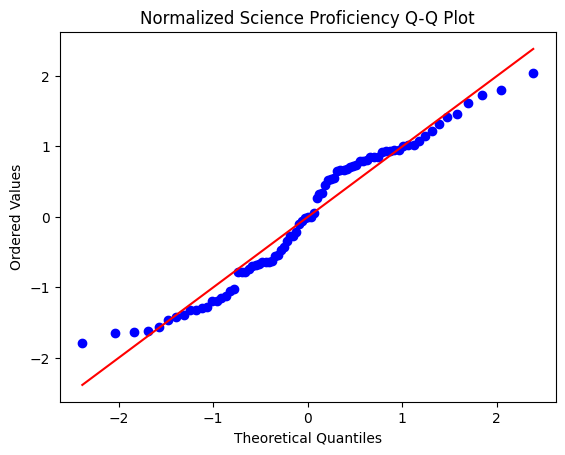

In [11]:
stats.probplot(dfPISA["Normalized_Scie"], dist="norm", plot=plt)
plt.title('Normalized Science Proficiency Q-Q Plot')
plt.xlabel('Theoretical Quantiles')
plt.ylabel('Ordered Values')
plt.show()

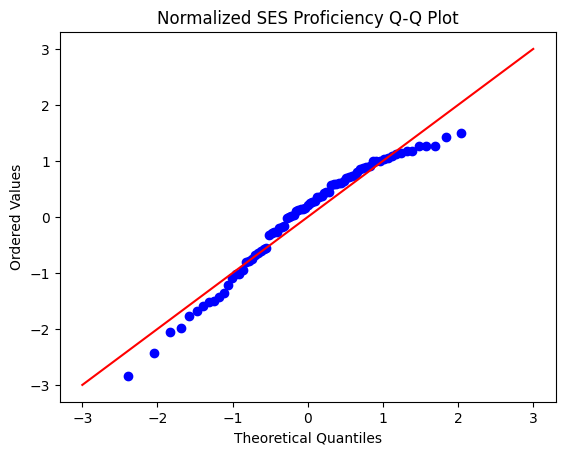

In [12]:
stats.probplot(dfPISA["Normalized_SES"], dist="norm", plot=plt)
ax = plt.gca()
xlim = [-3, 3]
ylim = [-3, 3]
ax.plot(xlim, ylim, color = "red", linestyle="-", clip_on=True, scalex=False, scaley=False)
plt.title('Normalized SES Proficiency Q-Q Plot')
plt.xlabel('Theoretical Quantiles')
plt.ylabel('Ordered Values')
plt.show()

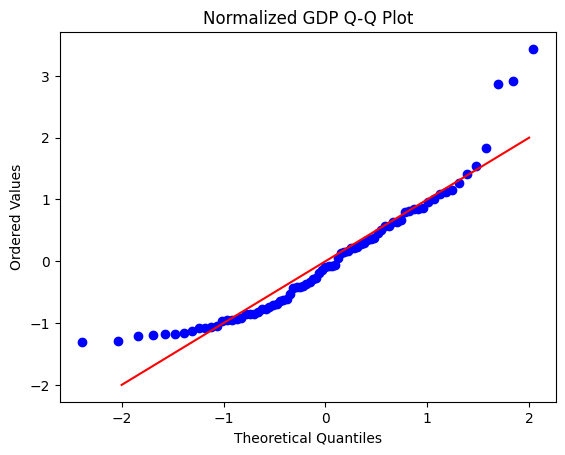

In [13]:
stats.probplot(dfPISA["Normalized_GDP"], dist="norm", plot=plt)
ax = plt.gca()
xlim = [-2, 2]
ylim = [-2, 2]
ax.plot(xlim, ylim, color = "red", linestyle="-", clip_on=True, scalex=False, scaley=False)
plt.title('Normalized GDP Q-Q Plot')
plt.xlabel('Theoretical Quantiles')
plt.ylabel('Ordered Values')
plt.show()

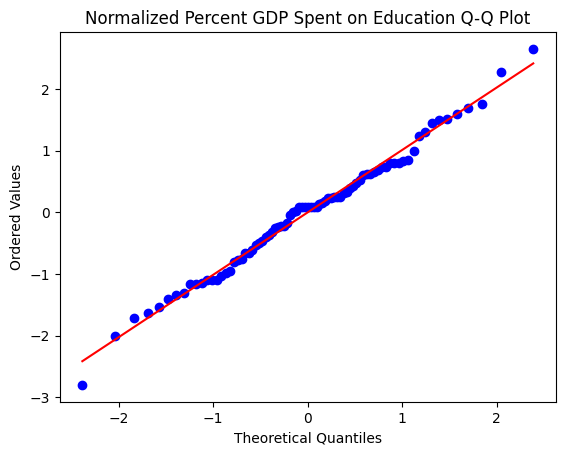

In [14]:
stats.probplot(dfPISA["Normalized_Ed_Percent_GDP"], dist="norm", plot=plt)
plt.title('Normalized Percent GDP Spent on Education Q-Q Plot')
plt.xlabel('Theoretical Quantiles')
plt.ylabel('Ordered Values')
plt.show()